In [48]:
import pandas as pd 
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
daily_df = pd.read_excel('BB_Dataset_20240101_20240526.xlsx', sheet_name='Daily Sales', skiprows=3)
trans_df = pd.read_excel('BB_Dataset_20240101_20240526.xlsx', sheet_name='Transaction Data', skiprows=3)

In [3]:
daily_df.head()

,Date,Day,Month,Year,Week No,Weekday,# Bill,Unit,APT,UPT,Traffic,Conversion Rate,Revenue,Target by Day
0,2024-01-01,1,1,2024,1,1900-01-02,95,174,588350.526316,1.831579,166,0.572289,55893300,64400000
1,2024-01-02,2,1,2024,1,1900-01-03,71,117,602275.352113,1.647887,163,0.435583,42761550,64400000
2,2024-01-03,3,1,2024,1,1900-01-04,83,121,537895.180723,1.457831,267,0.310861,44645300,64400000
3,2024-01-04,4,1,2024,1,1900-01-05,121,201,563175.619835,1.661157,250,0.484000,68144250,64400000
4,2024-01-05,5,1,2024,1,1900-01-06,117,214,644031.196581,1.829060,240,0.487500,75351650,80500000


In [4]:
trans_df.head()

,Date,Day,Month,Year,Week No,Weekday,Hour,SKU-2,SKU-1,Product Category,Product Type,Order ID,Units,Discount,Revenue,Merchandise Type,Customer Type
0,2024-01-01,1,1,2024,1,1900-01-02,15:23:08,K2660-2,K2660,Set,Tiệc,#283578,2,0.0,898000.0,Hàng bán bth,Khách Hàng Mới
1,2024-01-01,1,1,2024,1,1900-01-02,16:46:14,K2660-1,K2660,Set,Tiệc,#283602,2,0.0,898000.0,Hàng bán bth,Khách Hàng Cũ
2,2024-01-01,1,1,2024,1,1900-01-02,16:08:41,K2836-1,K2836,Set,Áo dài,#283591,1,0.0,699000.0,Off mã,Khách Hàng Cũ
3,2024-01-01,1,1,2024,1,1900-01-02,11:52:02,D2928-1,D2928,Đầm,Tiệc,#283533,1,0.0,689000.0,Off mã,Khách Hàng Cũ
4,2024-01-01,1,1,2024,1,1900-01-02,19:25:01,K2794-2,K2794,Set,Tiệc,#283642,1,0.0,649000.0,Hàng bán bth,Khách Hàng Cũ


In [5]:
print('---- Daily Sales Info ---')
print('Columns:', daily_df.columns)
print('Rows:', len(daily_df))
print('Shape:', daily_df.shape)

print('\n---- Transaction Data Info ---')
print('Columns', trans_df.columns)
print('Rows:', len(trans_df))
print('Shape:', trans_df.shape)

---- Daily Sales Info ---
Columns: Index(['Date', 'Day', 'Month', 'Year', 'Week No', 'Weekday', '# Bill', 'Unit',
       'APT', 'UPT', 'Traffic', 'Conversion Rate', 'Revenue', 'Target by Day'],
      dtype='object')
Rows: 137
Shape: (137, 14)

---- Transaction Data Info ---
Columns Index(['Date', 'Day', 'Month', 'Year', 'Week No', 'Weekday', 'Hour', 'SKU-2',
       'SKU-1', 'Product Category', 'Product Type', 'Order ID', 'Units',
       'Discount', 'Revenue', 'Merchandise Type', 'Customer Type'],
      dtype='object')
Rows: 20622
Shape: (20622, 17)


---
## Transaction Data
---

In [6]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20622 entries, 0 to 20621
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              20622 non-null  datetime64[ns]
 1   Day               20622 non-null  int64         
 2   Month             20622 non-null  int64         
 3   Year              20622 non-null  int64         
 4   Week No           20622 non-null  int64         
 5   Weekday           20622 non-null  datetime64[ns]
 6   Hour              20622 non-null  object        
 7   SKU-2             13699 non-null  object        
 8   SKU-1             20622 non-null  object        
 9   Product Category  20622 non-null  object        
 10  Product Type      20622 non-null  object        
 11  Order ID          20622 non-null  object        
 12  Units             20622 non-null  int64         
 13  Discount          19684 non-null  float64       
 14  Revenue           2062

**Duplicate Rows**

In [7]:
print('\nDuplicate rows: ',trans_df.duplicated().sum())


Duplicate rows:  261


In [8]:
trans_df.drop_duplicates(inplace=True)

**Standardize norminal values**

In [9]:
for col in trans_df[['SKU-2','SKU-1', 'Product Category', 'Product Type', 'Merchandise Type', 'Customer Type']]:
    if trans_df[col].str.lower().unique().size<30:
        print(col, trans_df[col].unique())

Product Category ['Set' 'Đầm' 'Quần jean' 'Áo khoác' 'Quần dài' 'Áo kiểu' 'Chân váy dài'
 'Chân váy ngắn' 'Áo sơ mi' 'ÁO KIỂU' 'Phụ kiện' 'Jumpsuit' 'Khác'
 'Quần ngắn' 'Đầm Dài' 'Áo Thun' 'Quần Váy' 'Chân Váy Dài' 'Áo Kiểu'
 'Đầm Ngắn' 'Quần Dài' 'Áo Sơ Mi' 'Áo Blazer' 'Thắt Lưng' 'Quần Ngắn'
 'Quần Jean' 'Tag Cài' 'Chân Váy Jean' 'Nội Y' 'Chân Váy Ngắn' 'Hoa Cổ'
 'Khăn' 'Túi']
Product Type ['Tiệc' 'Áo dài' 'Lifestyle' 'Tiệc/ Công sở' 'Công sở' 'Phụ kiện' 'BST'
 'lifestyle']
Merchandise Type ['Hàng bán bth' 'Off mã' 'Hero' 'Đinh' 'Chưa phân loại' 'Phụ kiện'
 'hàng bán bth' 'hàng bán bth-off mã' 'Hàng mới đợt 1']
Customer Type ['Khách Hàng Mới' 'Khách Hàng Cũ']


There are values written in different ways, and some of the values overlap with the other (hàng bán bth-off mã & hàng bán bth/off mã). However with the overlapping value like Tiệc/ Công Sở will be keep remained as it shows multi-value of the product. Tiệc or Công Sở alone would not completely describe this type.

In [37]:
for col in trans_df[['Product Category', 'Product Type', 'Merchandise Type']]:
    trans_df[col]=trans_df[col].str.lower()
    print(col, trans_df[col].unique())
    # print(trans_df[col].value_counts())

trans_df.loc[trans_df['Merchandise Type'] == 'hàng bán bth-off mã', 'Merchandise Type'] = 'hàng bán bth'

print(f'\nProduct Category: {len(trans_df["Product Category"].unique())}, '
      f'Product Type: {len(trans_df["Product Type"].unique())}, '
      f'Merchandise Type: {len(trans_df["Merchandise Type"].unique())}')

Product Category ['set' 'đầm' 'quần jean' 'áo khoác' 'quần dài' 'áo kiểu' 'chân váy dài'
 'chân váy ngắn' 'áo sơ mi' 'phụ kiện' 'jumpsuit' 'khác' 'quần ngắn'
 'đầm dài' 'áo thun' 'quần váy' 'đầm ngắn' 'áo blazer' 'thắt lưng'
 'tag cài' 'chân váy jean' 'nội y' 'hoa cổ' 'khăn' 'túi']
Product Type ['tiệc' 'áo dài' 'lifestyle' 'tiệc/ công sở' 'công sở' 'phụ kiện' 'bst']
Merchandise Type ['hàng bán bth' 'off mã' 'hero' 'đinh' 'chưa phân loại' 'phụ kiện'
 'hàng bán bth-off mã' 'hàng mới đợt 1']

Product Category: 25, Product Type: 7, Merchandise Type: 7


**Missing Value**

In [11]:
null_trans = trans_df.isnull().sum().to_frame(name='Null Count')
null_trans['Null Percentage'] = null_trans['Null Count']/trans_df.shape[0]*100
null_trans.round(2)

,Null Count,Null Percentage
Date,0,0.00
Day,0,0.00
Month,0,0.00
Year,0,0.00
Week No,0,0.00
Weekday,0,0.00
Hour,0,0.00
SKU-2,6662,32.72
SKU-1,0,0.00
Product Category,0,0.00


In [13]:
missing_sku = trans_df[trans_df['SKU-2'].isnull()==True]
missing_sku.head()

,Date,Day,Month,Year,Week No,Weekday,Hour,SKU-2,SKU-1,Product Category,Product Type,Order ID,Units,Discount,Revenue,Merchandise Type,Customer Type
13699,2024-04-01,1,4,2024,14,1900-01-02,21:00:00,NaN,D3380,đầm,tiệc,#297110,1,0.0,439000.0,hàng bán bth-off mã,Khách Hàng Cũ
13700,2024-04-01,1,4,2024,14,1900-01-02,21:00:00,NaN,A2607,áo kiểu,tiệc/ công sở,#297110,1,0.0,265000.0,hero,Khách Hàng Cũ
13701,2024-04-01,1,4,2024,14,1900-01-02,21:00:00,NaN,A3280,áo sơ mi,công sở,#297109,1,-12950.0,246050.0,hàng bán bth,Khách Hàng Cũ
13702,2024-04-01,1,4,2024,14,1900-01-02,21:00:00,NaN,A2291,áo khoác,công sở,#297109,1,-220000.0,219000.0,off mã,Khách Hàng Cũ
13703,2024-04-01,1,4,2024,14,1900-01-02,21:00:00,NaN,K2660,set,tiệc,#297108,1,0.0,449000.0,hàng bán bth,Khách Hàng Cũ


In [14]:
missing_sku['Date'].unique()

<DatetimeArray>
['2024-04-01 00:00:00', '2024-04-02 00:00:00', '2024-04-03 00:00:00',
 '2024-04-04 00:00:00', '2024-04-05 00:00:00', '2024-04-06 00:00:00',
 '2024-04-07 00:00:00', '2024-04-08 00:00:00', '2024-04-09 00:00:00',
 '2024-04-10 00:00:00', '2024-04-11 00:00:00', '2024-04-12 00:00:00',
 '2024-04-13 00:00:00', '2024-04-14 00:00:00', '2024-04-15 00:00:00',
 '2024-04-16 00:00:00', '2024-04-17 00:00:00', '2024-04-18 00:00:00',
 '2024-04-19 00:00:00', '2024-04-20 00:00:00', '2024-04-21 00:00:00',
 '2024-04-22 00:00:00', '2024-04-23 00:00:00', '2024-04-24 00:00:00',
 '2024-04-25 00:00:00', '2024-04-26 00:00:00', '2024-04-27 00:00:00',
 '2024-04-28 00:00:00', '2024-04-29 00:00:00', '2024-04-30 00:00:00',
 '2024-05-01 00:00:00', '2024-05-02 00:00:00', '2024-05-03 00:00:00',
 '2024-05-04 00:00:00', '2024-05-05 00:00:00', '2024-05-06 00:00:00',
 '2024-05-07 00:00:00', '2024-05-08 00:00:00', '2024-05-09 00:00:00',
 '2024-05-10 00:00:00', '2024-05-11 00:00:00', '2024-05-12 00:00:00',
 '20

SKU-2 indicates the variants of SKU-1 and missing values in SKU-2 appears in specific time: 01/04/2024 - 20/05/2024. This can be infered that the stores stop storing variants for the SKU-1. There are no logical reasoning to impute on this column so it would be filled with 'noinf' 

In [38]:
trans_df['SKU-2'].fillna('noinf', inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25200\1376816762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  trans_df['SKU-2'].fillna('noinf', inplace=True)


In [39]:
print('Discount unique values:', trans_df.Discount.unique().size)
print('\nNumber of discount among merchandise type')
print(trans_df[trans_df['Discount'].isnull()==False]['Merchandise Type'].value_counts().to_frame())
print('\nNumber of discount among customer type')
print(trans_df[trans_df['Discount'].isnull()==False]['Customer Type'].value_counts().to_frame())

Discount unique values: 1049

Number of discount among merchandise type
                  count
Merchandise Type       
hàng bán bth       5799
hero               5070
off mã             4687
đinh               2830
phụ kiện           1551
hàng mới đợt 1      415
chưa phân loại        9

Number of discount among customer type
                count
Customer Type        
Khách Hàng Cũ   14069
Khách Hàng Mới   6292


Only 887 rows are missing discount values (~4%) and there is no specific pattern for applying discount, therefore it's resonable to assume that the discount of these rows is 0.

In [40]:
trans_df.Discount.fillna(0, inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25200\2790887212.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  trans_df.Discount.fillna(0, inplace=True)


**Handling Outliers**

In [18]:
trans_df.dtypes

Date                datetime64[ns]
Day                          int64
Month                        int64
Year                         int64
Week No                      int64
Weekday             datetime64[ns]
Hour                        object
SKU-2                       object
SKU-1                       object
Product Category            object
Product Type                object
Order ID                    object
Units                        int64
Discount                   float64
Revenue                    float64
Merchandise Type            object
Customer Type               object
dtype: object

In [19]:
trans_df.describe(include='object')

,Hour,SKU-2,SKU-1,Product Category,Product Type,Order ID,Merchandise Type,Customer Type
count,20361,13699,20361,20361,20361,20361,20361,20361
unique,6944,1844,544,25,7,11273,8,2
top,20:00:00,BST169,BBQ1671S,đầm,tiệc,#288052,hero,Khách Hàng Cũ
freq,980,80,453,6022,8964,26,5070,14069


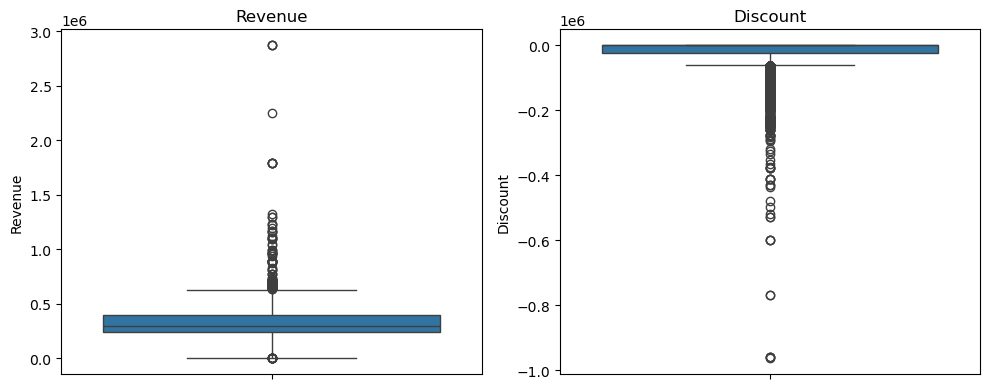

In [20]:
plt.figure(figsize=(10,4))

# Subplot 1: Revenue
plt.subplot(1,2,1)
sns.boxplot(trans_df.Revenue)
plt.title("Revenue")

# Subplot 2: Discount
plt.subplot(1,2,2)
sns.boxplot(trans_df.Discount)
plt.title("Discount")

plt.tight_layout()
plt.show()

In [21]:
print('Revenue Range: ', trans_df.Revenue.max()-trans_df.Revenue.min())
print('Discount Range: ', trans_df.Discount.abs().max()-trans_df.Discount.abs().min())

Revenue Range:  2874000.0
Discount Range:  963900.0


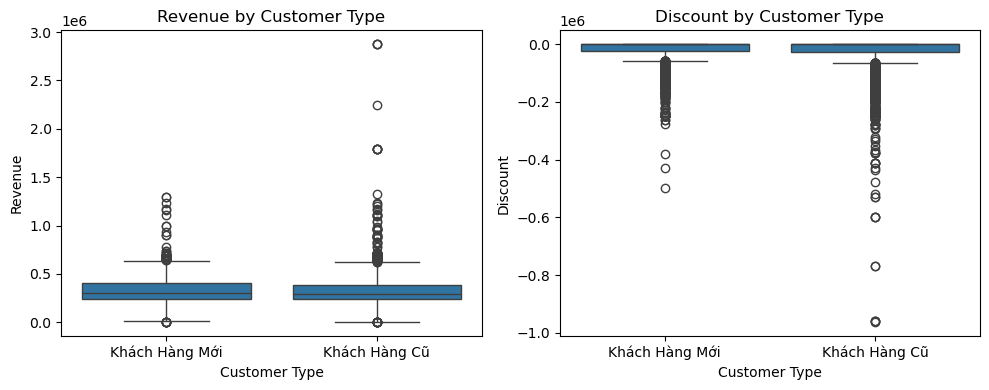

In [22]:
plt.figure(figsize=(10,4))

# Revenue
plt.subplot(1,2,1)
sns.boxplot(data=trans_df, x='Customer Type', y='Revenue')
plt.title("Revenue by Customer Type")

# Discount
plt.subplot(1,2,2)
sns.boxplot(data=trans_df, x='Customer Type', y='Discount')
plt.title("Discount by Customer Type")

plt.tight_layout()
plt.show()

In [41]:
Q1 = trans_df.Revenue.quantile(0.25)
Q3 = trans_df.Revenue.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rev_out = trans_df[(trans_df.Revenue < lower) | (trans_df.Revenue > upper)]

print('Revenue out of IQR: ', rev_out.shape[0])
print('Percentage: ', rev_out.shape[0]/trans_df.shape[0]*100)

Revenue out of IQR:  199
Percentage:  0.9773586759000049


In [70]:
rev_out.sort_values(by='Revenue', ascending=False).head()

,Date,Day,Month,Year,Week No,Weekday,Hour,SKU-2,SKU-1,Product Category,Product Type,Order ID,Units,Discount,Revenue,Merchandise Type,Customer Type
4950,2024-01-22,22,1,2024,4,1900-01-02,21:29:10,D3027-2,D3027,đầm,tiệc,#288052,8,-958000.0,2874000.0,hàng bán bth,Khách Hàng Cũ
4949,2024-01-22,22,1,2024,4,1900-01-02,21:29:10,D3027-3,D3027,đầm,tiệc,#288052,8,-958000.0,2874000.0,hàng bán bth,Khách Hàng Cũ
4951,2024-01-22,22,1,2024,4,1900-01-02,21:29:10,D3027-1,D3027,đầm,tiệc,#288052,8,-958000.0,2874000.0,hàng bán bth,Khách Hàng Cũ
4952,2024-01-22,22,1,2024,4,1900-01-02,21:29:10,D2390-3,D2390,đầm,tiệc,#288052,7,-963900.0,2249100.0,off mã,Khách Hàng Cũ
4955,2024-01-22,22,1,2024,4,1900-01-02,21:29:10,D3100-6,D3100,đầm,tiệc,#288052,6,-598500.0,1795500.0,off mã,Khách Hàng Cũ


Further examining the outlier of Revenue, the top revenue transactions often involve buying large amount of units and coming from members. This seems resonable, but still necesary to check if there exists transaction with small units but high revenue.

<Axes: xlabel='Units', ylabel='Revenue'>

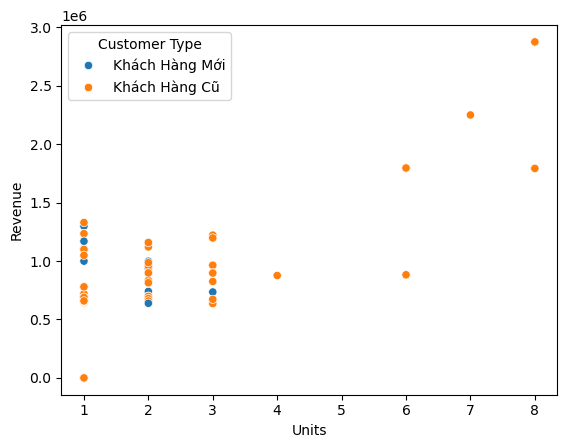

In [ ]:
sns.scatterplot(rev_out, x='Units', y='Revenue', hue='Customer Type')

In [87]:
# check the variance of revenue
print(rev_out[rev_out['Units']==1]['Product Category'].value_counts().to_frame())

# check for 0 revenue
print('\n0 revenue transactions: ', rev_out[rev_out.Revenue==0].shape[0])
print('Exist of discount in 0 revenue transactions: ', len(rev_out[(rev_out['Units']==1)&(rev_out.Revenue==0)]['Discount'].abs()>0))

                  count
Product Category       
đầm                  70
set                  57
phụ kiện              7
quần dài              3
chân váy dài          2
đầm dài               2
túi                   2
quần jean             1
áo khoác              1

0 revenue transactions:  17
Exist of discount in 0 revenue transactions:  17


In [42]:
Q1 = trans_df.Discount.quantile(0.25)
Q3 = trans_df.Discount.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dis_out = trans_df[(trans_df.Discount < lower) | (trans_df.Discount > upper)]

print('Discount out of IQR: ', dis_out.shape[0])
print('Percentage: ', dis_out.shape[0]/trans_df.shape[0]*100)

Discount out of IQR:  2294
Percentage:  11.266637198565887


In [49]:
# map weekday to monday, tuesday, wednesday, thursday, friday, saturday, sunday
trans_df.Weekday = trans_df.Date.dt.day_name().str.lower()
trans_df.Weekday.unique()

array(['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
       'sunday'], dtype=object)

In [50]:
trans_df.to_excel('D:\BB_Analysis\Transaction_Data.xlsx', index=False)

---
## Daily Sales
---

**Check for Missing and Duplicate Data**: There are no missing or duplicate data

In [28]:
daily_df.isnull().sum()

Date               0
Day                0
Month              0
Year               0
Week No            0
Weekday            0
# Bill             0
Unit               0
APT                0
UPT                0
Traffic            0
Conversion Rate    0
Revenue            0
Target by Day      0
dtype: int64

In [29]:
daily_df.duplicated().sum()

np.int64(0)

In [30]:
daily_df.columns

Index(['Date', 'Day', 'Month', 'Year', 'Week No', 'Weekday', '# Bill', 'Unit',
       'APT', 'UPT', 'Traffic', 'Conversion Rate', 'Revenue', 'Target by Day'],
      dtype='object')

Need to re-calculate relevant metrics because there are some changes in the transaction data.

In [31]:
daily_df['Unit'] = daily_df['Date'].map(trans_df.groupby('Date')['Units'].sum())

In [32]:
# Revenue
daily_df.Revenue = daily_df['Date'].map(trans_df.groupby('Date')['Revenue'].sum())

# APT, UPT, Conversion Rate
daily_df.APT = daily_df.Revenue/daily_df['# Bill']
daily_df.UPT = daily_df.Unit/daily_df['# Bill']
daily_df['Conversion Rate'] = daily_df['# Bill']/daily_df.Traffic

In [54]:
daily_df.Weekday = daily_df.Date.dt.day_name().str.lower()
daily_df.head()

,Date,Day,Month,Year,Week No,Weekday,# Bill,Unit,APT,UPT,Traffic,Conversion Rate,Revenue,Target by Day
0,2024-01-01,1,1,2024,1,monday,95,174,592866.315789,1.831579,166,0.572289,56322300.0,64400000
1,2024-01-02,2,1,2024,1,tuesday,71,116,612120.422535,1.633803,163,0.435583,43460550.0,64400000
2,2024-01-03,3,1,2024,1,wednesday,83,121,537895.180723,1.457831,267,0.310861,44645300.0,64400000
3,2024-01-04,4,1,2024,1,thursday,121,201,585878.099174,1.661157,250,0.484000,70891250.0,64400000
4,2024-01-05,5,1,2024,1,friday,117,214,648552.564103,1.829060,240,0.487500,75880650.0,80500000


In [58]:
daily_df.Month = daily_df.Date.dt.month_name().str.lower()
daily_df.head()

,Date,Day,Month,Year,Week No,Weekday,# Bill,Unit,APT,UPT,Traffic,Conversion Rate,Revenue,Target by Day
0,2024-01-01,1,january,2024,1,monday,95,174,592866.315789,1.831579,166,0.572289,56322300.0,64400000
1,2024-01-02,2,january,2024,1,tuesday,71,116,612120.422535,1.633803,163,0.435583,43460550.0,64400000
2,2024-01-03,3,january,2024,1,wednesday,83,121,537895.180723,1.457831,267,0.310861,44645300.0,64400000
3,2024-01-04,4,january,2024,1,thursday,121,201,585878.099174,1.661157,250,0.484000,70891250.0,64400000
4,2024-01-05,5,january,2024,1,friday,117,214,648552.564103,1.829060,240,0.487500,75880650.0,80500000


In [56]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             137 non-null    datetime64[ns]
 1   Day              137 non-null    int64         
 2   Month            137 non-null    int64         
 3   Year             137 non-null    int64         
 4   Week No          137 non-null    int64         
 5   Weekday          137 non-null    object        
 6   # Bill           137 non-null    int64         
 7   Unit             137 non-null    int64         
 8   APT              137 non-null    float64       
 9   UPT              137 non-null    float64       
 10  Traffic          137 non-null    int64         
 11  Conversion Rate  137 non-null    float64       
 12  Revenue          137 non-null    float64       
 13  Target by Day    137 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(8)

In [60]:
daily_df.to_excel('D:\BB_Analysis\Daily_Sales.xlsx', index=False)